<a href="https://colab.research.google.com/github/sabithakrishnan/Survival-Models/blob/main/XGboostSurvival.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost scikit-survival pandas matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 4.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 102.3 MB/s eta 0:00:00
  Created wheel for ecos: filename=ecos-2.0.14-cp313-cp313-linux_x86_64.whl size=204011 sha256=6da60a4573bfa01bc975c5796b61ff6e8ca1bff21703032efdc627eb7374d8b2
  Stored in directory: /root/.cache/pip/wheels/6b/82/0b/4bb5aa6c4618f367601a45db8710205d56858808423974e92a
Successfully built ecos
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


XGBoost Model C-Index: 0.8487


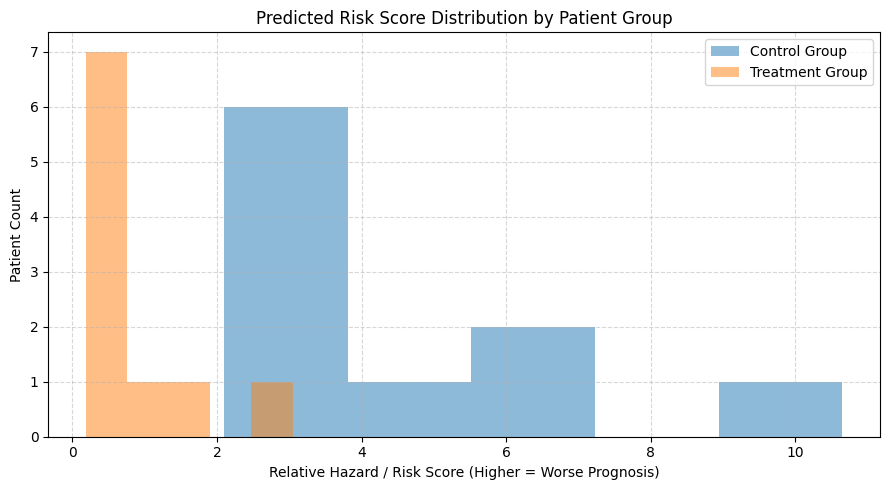

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sksurv.metrics import concordance_index_censored

# 1. Prepare sample data
# XGBoost Cox objective requires:
# - Target > 0 for events that occurred
# - Target < 0 (negative value) for censored cases
data = {
    'duration': [5, 6, 6, 2.5, 7, 8.5, 12, 15, 18, 20, 12, 14, 19, 22, 24, 25, 28, 30, 32, 36],
    'event_observed': [1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1], # Added sample data
    'is_treatment': [0]*10 + [1]*10, # Fixed to create a list of 0s and 1s (10 controls, 10 treatments)
    'age': [54, 62, 45, 71, 58, 66, 49, 52, 60, 68, 55, 61, 47, 70, 57, 64, 50, 53, 59, 67]
}
df = pd.DataFrame(data)

# Transform the labels for XGBoost Cox requirements
# If event is observed, target = duration. If censored, target = -duration.
df['target'] = df['duration'] * np.where(df['event_observed'] == 1, 1, -1)

# Split features (X) and target label (y)
X = df[['is_treatment', 'age']]
y = df['target']

# 2. Configure and train the XGBoost model
# Use 'survival:cox' as the training objective
params = {
    'objective': 'survival:cox',
    'eval_metric': 'cox-nloglik',
    'learning_rate': 0.1,
    'max_depth': 3,
    'seed': 42
}

dtrain = xgb.DMatrix(X, label=y)
bst = xgb.train(params, dtrain, num_boost_round=50)

# 3. Predict Hazard Scores (Risk Scores)
# Higher score = higher risk of the event happening sooner
risk_scores = bst.predict(dtrain)
df['risk_score'] = risk_scores

# 4. Evaluate the model performance using Concordance Index (C-Index)
# A score of 0.5 is random guessing; 1.0 is a perfect model prediction.
c_index = concordance_index_censored(
    df['event_observed'].astype(bool),
    df['duration'],
    df['risk_score']
)
print(f"XGBoost Model C-Index: {c_index[0]:.4f}")

# 5. Visualize the Relative Patient Risk Profiles
# Group patients by their assigned risk profile to view distribution shifts
plt.figure(figsize=(9, 5))
for group_name, group_df in df.groupby('is_treatment'):
    label = 'Treatment Group' if group_name == 1 else 'Control Group'
    plt.hist(group_df['risk_score'], alpha=0.5, label=label, bins=5)

plt.title('Predicted Risk Score Distribution by Patient Group')
plt.xlabel('Relative Hazard / Risk Score (Higher = Worse Prognosis)')
plt.ylabel('Patient Count')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sksurv.metrics import concordance_index_censored

# 1. Prepare sample data
data = {
    'duration': [5, 6, 6, 2.5, 7, 8.5, 12, 15, 18, 20, 12, 14, 19, 22, 24, 25, 28, 30, 32, 36],
    'event_observed': [1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1],
    'is_treatment': [0]*10 + [1]*10,
    'age': [54, 62, 45, 71, 58, 66, 49, 52, 60, 68, 55, 61, 47, 70, 57, 64, 50, 53, 59, 67]
}
df = pd.DataFrame(data)

# 2. Format target for survival:aft (lower and upper bounds)
y_lower = df['duration'].values
# For censored data (0), upper bound is infinity. For observed events (1), it equals the duration.
y_upper = np.where(df['event_observed'] == 1, df['duration'].values, np.inf)

X = df[['is_treatment', 'age']]

# 3. Configure and train XGBoost AFT
# We must set the 'aft_loss_distribution' (choices: normal, logistic, extreme)
params = {
    'objective': 'survival:aft',
    'eval_metric': 'aft-nloglik',
    'aft_loss_distribution': 'normal',
    'aft_loss_distribution_scale': 1.20,
    'learning_rate': 0.05,
    'max_depth': 3,
    'seed': 42
}

# Create DMatrix and pass lower/upper bounds as the label using a column stack
# The 'label' for AFT models expects a 2-column array: [lower_bound, upper_bound]
dtrain = xgb.DMatrix(X, label=np.column_stack([y_lower, y_upper]))

bst = xgb.train(params, dtrain, num_boost_round=100)

# 4. Predict time-to-event
# survival:aft outputs the predicted log-survival time: ln(t)
log_pred_time = bst.predict(dtrain)
df['predicted_time'] = np.exp(log_pred_time)  # Convert back to actual timeline units

# 5. Evaluate with C-Index
# Note: C-index expects a risk score (higher = worse). Since predicted time is opposite
# (higher = better), we invert it by using a negative sign.
risk_scores = -df['predicted_time']
c_index = concordance_index_censored(
    df['event_observed'].astype(bool),
    df['duration'],
    risk_scores
)
print(f"XGBoost AFT Model C-Index: {c_index[0]:.4f}")

# 6. Plot Predicted vs Actual Survival Times
plt.figure(figsize=(9, 5))
plt.scatter(df[df['event_observed']==1]['duration'], df[df['event_observed']==1]['predicted_time'], color='crimson', label='Actual Events', alpha=0.8)
plt.scatter(df[df['event_observed']==0]['duration'], df[df['event_observed']==0]['predicted_time'], color='dodgerblue', label='Censored (Minimum Time)', alpha=0.5, marker='x')

plt.plot([0, 40], [0, 40], 'k--', alpha=0.5, label='Perfect Prediction Identity')
plt.title('XGBoost AFT: Predicted vs. Actual Timeline')
plt.xlabel('Observed Duration')
plt.ylabel('Predicted Survival Time')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

XGBoostError: [13:35:27] /__w/xgboost/xgboost/src/data/data.cc:568: Check failed: valid: Label contains NaN, infinity or a value too large.
Stack trace:
  [bt] (0) /usr/local/lib/python3.13/dist-packages/xgboost/lib/libxgboost.so(+0x21ec5c) [0x7b3ca5c1ec5c]
  [bt] (1) /usr/local/lib/python3.13/dist-packages/xgboost/lib/libxgboost.so(+0x50cb59) [0x7b3ca5f0cb59]
  [bt] (2) /usr/local/lib/python3.13/dist-packages/xgboost/lib/libxgboost.so(+0x50daf5) [0x7b3ca5f0daf5]
  [bt] (3) /usr/local/lib/python3.13/dist-packages/xgboost/lib/libxgboost.so(XGDMatrixSetInfoFromInterface+0xe4) [0x7b3ca5b28884]
  [bt] (4) /lib/x86_64-linux-gnu/libffi.so.8(+0x7b16) [0x7b3ce71f4b16]
  [bt] (5) /lib/x86_64-linux-gnu/libffi.so.8(+0x43ef) [0x7b3ce71f13ef]
  [bt] (6) /lib/x86_64-linux-gnu/libffi.so.8(ffi_call+0x12e) [0x7b3ce71f40be]
  [bt] (7) /usr/lib/python3.13/lib-dynload/_ctypes.cpython-313-x86_64-linux-gnu.so(+0x16d26) [0x7b3ce71acd26]
  [bt] (8) /usr/lib/python3.13/lib-dynload/_ctypes.cpython-313-x86_64-li